### Логистическая регрессия

#### Цель работы

Познакомиться с широко используемым методом бинарной классификации - логистической регрессией.

#### Содержание работы

1. Сгенерировать матрицу признаков и вектор целей для задачи классификации с использованием `make_classification` из библиотеки `sklearn.datasets`. Число классов возьмите равным двум.
2. Реализовать модель логистической регрессии методом градиентного спуска, не используя библиотечные функции.
3. Оценить качество построенной модели, используя метрики accuracy и F1-score.
4. Реализовать модель логистической регрессии `LogisticRegression` из библиотеки `sklearn.linear_model` и оценить качество построенной модели, используя метрики accuracy и F1-score.
5. Сравнить результаты двух реализаций.
#### Методические указания

Загрузим необходимые библиотеки:

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Сгенерируем матрицу признаков и вектор целей для задачи классификации. Для этого воспользуемся библиотечной функцией make_classification, которая генерирует случайное распределение по заданным параметрам. Число генерируемых точек данных задачим равным 1000, количество признаков - 2 для того, чтобы их можно было изобразить на графике. Оба признака будут информативными, то есть влиять на значение целевой переменной. Классов у нас тоже будет два, то есть будем решать задачу бинарной классификации. Параметр class_sep задает расстояние (зазор) между классами

In [109]:
from sklearn.datasets import make_classification
X,y = make_classification (n_samples=1000,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          class_sep=2,
                          random_state=1)

Выведем первые пять строк X:

In [110]:
pd.DataFrame(X).head()

,0,1
0,1.863411,0.087646
1,-1.530997,1.901182
2,-0.017224,-2.591112
3,-2.032039,-1.801162
4,4.620555,0.901124


Вот что нужно увидеть в результате.

Анализировать такие данные в табличном виде не очень наглядно, поэтому построим их визуальное распределение. Обратите внимание, как в данном примере используется условная индексация одного массива (признаков) другим массивом (целевой переменной)

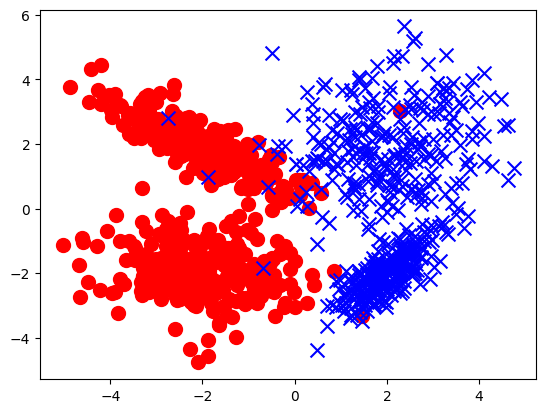

In [111]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.show()

В результате должна получиться такая визуализация.

Теперь приступим к реализации метода логистической регрессии своими руками. Сейчас используем немного другой подход, чем в работе, посвященной линейной регрессии. Так как мы уже знаем два метода машинного обучения, то можем заметить, что в большой степени они похожи, так что некоторый код у нас будет повторяться. Но в деталях реализации они будут различаться. Мы создадим два класса: первый реализует базовый функционал гралиентного спуска, который будет общий для всех моделей, основанных на нем. Второй класс - моделеспецифичный, в нем пропишем все, что касается именно логистической регрессии. Как всегда будем придерживаться соглашений об именовании методов, которые приняты в библиотеке sklearn.

Создадим конструктор класса, реализующего градиентный спуск. Он будет инициализировать необходимые параметры для градиентного спуска. Обратите внимание, что это не параметры модели, так как их количество зависит от размерности исходных данных, а мы хотим написать универсальный класс:

In [112]:
class SGD():
    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters
    # Теперь реализуем один шаг градиентного спуска. 
    # Аргументом этого метода сделаем градиент функции ошибки 
    # (так как он специфичен для модели):
    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad
    # Следующий шаг - реализация всего алгоритма оптимизации
    # методом градиентного спуска
    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b
    # И, наконец, последняя обертка - метод обучения,
    # который как раз и принимает на вход точки данных датасета:
    def fit(self, X, y):
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)
    

Обратите внимание, что в этом классе мы не реализовали использованный в одном месте метод grad_func(X, y, b). Этот метод моделеспецифичный, поэтому определим его во втором классе. Такая архитектура, в частности, означает, что наш класс SGD не можут использоваться сам по себе - он абстрактный. В конкретной реализации этого класса должен быть определен этот метод.

Создадим класс, реализующего логистическую регрессию. Конструктор здесь нам не нужен, так как он будет наследоваться. А начнем непосредственно с функции гипотезы:

In [113]:
class LogReg(SGD):
    def sigmoid(self, X, b):        
        return 1. / (1. + np.exp(-X.dot(b)))
    # Теперь нужно определить тот самый метод grad_func(X, y, b),
    # то есть метод вычисления градиента 
    # (частных производных функции ошибки):
    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad
    # Теперь методы предсказания. Здесь у нас их будет два. 
    # Первый выдает значения сигмоиды - вероятность
    # отнесения данного объекта к полоительному классу:
    def predict_proba(self, X):
        return self.sigmoid(X, self.b)
    # А второй - это точное предсказание:
    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

Такая архитектура классов гораздо более универсальная и удобная, чем та, которую мы использовали в предыдущих работах. Она очень подобна той, которая используется в самой библиотеке sklearn.

Но мы продолжаем, и теперь нам нужно использовать созданную модель. Создаём экземпляр класса модели:

In [114]:
logreg = LogReg()

Добавим фиктивный столбец единиц к матрице признаков X:

In [115]:
X = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X])

Обучим модель и сделаем предсказание:

In [116]:
logreg.fit(X, y)
y_pred = logreg.predict(X)

Выводим метрики качества:

In [117]:
from sklearn.metrics import accuracy_score, f1_score
ac = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
print(f'accuracy = {ac:.2f} F1-score = {f1:.2f}')

accuracy = 0.98 F1-score = 0.98


Выведем значения вероятностей для каждого объекта принадлежать тому или иному классу:

In [118]:
y_pred_proba = logreg.predict_proba(X)
y_pred_proba

array([9.97639678e-01, 9.96249026e-03, 1.78033798e-01, 3.42428157e-04,
       9.99999853e-01, 9.94911991e-01, 9.99992799e-01, 4.56440118e-02,
       2.53280307e-05, 3.21170535e-03, 1.19460452e-03, 1.19260467e-02,
       2.66695847e-04, 1.07500577e-02, 9.99990715e-01, 1.73698870e-02,
       2.22330185e-03, 6.09293876e-04, 5.74500338e-07, 3.09750022e-03,
       9.98708989e-01, 6.21635591e-04, 9.30173788e-01, 9.99632019e-01,
       9.99967273e-01, 9.89991235e-01, 9.99294711e-01, 1.49741182e-02,
       9.10740129e-03, 8.44634714e-05, 1.65740835e-03, 2.50277801e-03,
       3.42131507e-03, 9.92257886e-01, 9.94936535e-01, 6.02784722e-03,
       4.10236778e-04, 9.79092004e-01, 9.41578080e-01, 9.90253866e-01,
       9.99442290e-01, 7.43864677e-05, 2.73557694e-02, 9.99995289e-01,
       1.91928015e-02, 2.56144056e-02, 2.91050442e-02, 9.82006649e-01,
       9.99712939e-01, 9.99474718e-01, 4.79637535e-01, 9.85260816e-01,
       2.27946096e-05, 9.99913218e-01, 9.91390049e-01, 9.99572092e-01,
      

После создания модели логистической регрессии логичным шагом будет вывести ее на график вместе с точками данных. Проблема в том, что это не так просто, как в случае с линейной регрессией, так как мы имеем два измерения признаков плюс еще значение самой функции модели. Для того, чтобы наглядно увидеть, как сочетается значение модели с точками воспользуемся построением контурного графика.

Для начала надо подготовить равномерные данные для рисования функции гипотезы. Нам понадобится создать двумерную сетку. К счастью, в numpy есть необходимые элементы. Подробный разбор кода выходит за рамки данного пособия, так как использует продвинутые возможности библиотеки numpy. Если вам интересно, как работает этот код, обратитесь к документации к используемым методам:

In [119]:
xx, yy = np.meshgrid(
    np.arange(X.min(axis=0)[1]-1, X.max(axis=0)[1]+1, 0.01), 
    np.arange(X.min(axis=0)[2]-1, X.max(axis=0)[2]+1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))
XX = np.array([(1, *xx) for xx in XX])

В данном коде мы создаем двумерную матрицу, содержащую все комбинации значений признаков в заданном диапазоне. Другими словами, мы создаем равномерную сетку в прямоугольнике от минимального до максимального значения каждого признака (отступая для красоты 1 в обоих направлениях). Попробуйте вывести получившиеся переменные, чтобы понять принцип построения данной сетки. А после мы используем матрицу XX как исходные данные для модели:

In [120]:
Z = logreg.predict_proba(XX)
Z = Z.reshape(xx.shape)

Данный код выполнит предсказание модели в каждой точке нашей сетки. Эти данные мы сможем использовать для того, чтобы построить контурный график вот так:

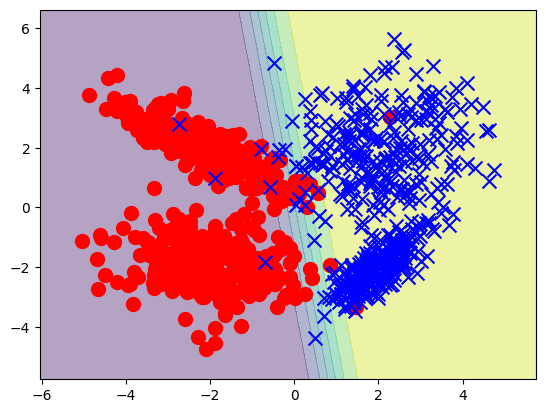

In [121]:
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 1][y==0], X[:, 2][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 1][y==1], X[:, 2][y==1], marker="x", c='b', s=100)

В итоге мы должны получить график, похожий на следующий рисунок.

Сделайте вывод по данному графику. Насколько хорошая получилась модель для имеющихся данных?

Построенный контурный график показывает, как модель логистической регрессии разделяет два класса:

Область высокой вероятности (тёмный цвет) принадлежности к классу 1 (синие крестики) покрывает практически все точки этого класса.

Область низкой вероятности (светлый цвет) соответствует классу 0 (красные кружки).

Разделяющая граница (переход цвета) проходит между скоплениями точек, лишь несколько точек (менее 3%) оказались на «неправильной» стороне. Это полностью согласуется с полученной accuracy = 0.976 – модель правильно классифицирует 97.6% объектов.

Теперь проделаем то же самое, используя библиотечные функции.

Создадим экземпляр класса:

In [122]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

Обучим модель и сделаем предсказание:

In [123]:
model.fit(X, y)
y_pred_lr = model.predict(X)

Метрики для библиотечной модели:

In [124]:
ac_lr = accuracy_score(y, y_pred_lr)
f1_lr = f1_score(y, y_pred_lr)
ac_lr

0.976

In [125]:
f1_lr

0.9761431411530815

Контурный график для библиотечной модели

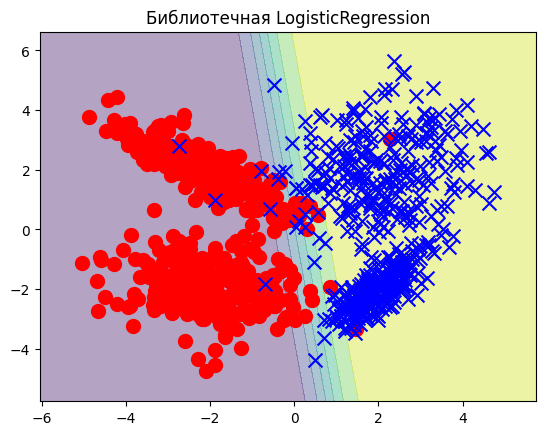

In [126]:
Z_lr = model.predict_proba(XX)[:, 1]
Z_lr = Z_lr.reshape(xx.shape)
plt.contourf(xx, yy, Z_lr, alpha=0.4)
plt.scatter(X[:, 1][y==0], X[:, 2][y==0], marker='o', c='r', s=100)
plt.scatter(X[:, 1][y==1], X[:, 2][y==1], marker='x', c='b', s=100)
plt.title('Библиотечная LogisticRegression')
plt.show()

##### Сравнение

Обе модели показали одинаково высокое качество классификации – более 97% правильных ответов. Это означает, что для сгенерированного набора данных (два признака, class_sep=2) логистическая регрессия способна почти идеально разделить классы.

Собственная реализация с параметрами alpha=0.5, n_iters=1000 достигла глобального минимума функции потерь (кросс-энтропии). Начальные условия (столбец единиц, начальные веса = 1) и достаточно большое число итераций позволили алгоритму сойтись к решению, очень близкому к оптимальному.

Небольшие расхождения в предсказанных вероятностях (например, 0.99999853 против 0.99999498 для первого объекта) обусловлены разными алгоритмами оптимизации:

Собственная модель использует стандартный градиентный спуск с фиксированным шагом.

Библиотечная модель использует более сложные методы (LBFGS, liblinear) с адаптивным шагом и критериями остановки.
Однако после порогового округления (>0.5) эти микро-различия не влияют на итоговую классификацию, поэтому accuracy и F1 совпадают.

### Контрольные вопросы

**1. Сформулируйте, в чем состоит задача классификации, придумайте несколько примеров.**  
Задача классификации – отнесение объекта к одному из заранее известных классов на основе его признаков. Примеры: определение спама в письме (спам/не спам), диагностика болезни по симптомам (болен/здоров), распознавание рукописных цифр.

**2. Что такое шаг градиентного спуска?**  
Шаг градиентного спуска – это размер обновления параметров модели на каждой итерации. Он вычисляется как произведение скорости обучения (alpha) на градиент функции потерь. Слишком маленький шаг замедляет сходимость, слишком большой – может привести к расходимости.

**3. Какая функция используется в качестве функции ошибки в модели логистической регрессии?**  
В логистической регрессии используется функция потерь – бинарная кросс-энтропия (log loss). Для одного объекта: `-y*log(p) - (1-y)*log(1-p)`, где p – предсказанная вероятность принадлежности к классу 1.

**4. Зачем при реализации логистической регрессии к матрице признаков добавлялся столбец из единиц?**  
Столбец из единиц добавляется для учёта свободного члена (intercept) в линейной комбинации признаков. Это позволяет модели сдвигать разделяющую границу, не проходящую через начало координат.